<a href="https://colab.research.google.com/github/Chaitanya081/DSA0205_Computer-Vision-with-OpenCV/blob/main/CO4_AT3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Precision-Recall Comparison: Viola-Jones vs YOLO on a Face/Object Dataset

OpenCV version: 5.0.0

0: 448x640 11 persons, 5 traffic lights, 3 handbags, 280.9ms
Speed: 10.7ms preprocess, 280.9ms inference, 2.6ms postprocess per image at shape (1, 3, 448, 640)
Number of 'person' objects detected: 11


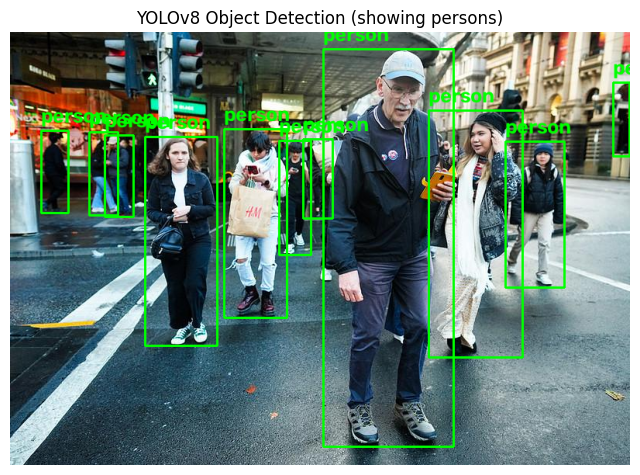

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


from ultralytics import YOLO

print("OpenCV version:", cv2.__version__)

model = YOLO('yolov8n.pt')


image = cv2.imread("face.jpg")

if image is None:
    print("Image not found. Please upload face.jpg to Colab.")
else:

    results = model(image)

    output_image = image.copy()
    person_count = 0
    # Get class names from the model
    class_names = model.names

    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].int().tolist()
            cls = int(box.cls[0]) # Get class index
            label = class_names[cls] # Get class name

            if label == 'person':
                cv2.rectangle(
                    output_image,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )
                person_count += 1

                cv2.putText(output_image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)


    print(f"Number of 'person' objects detected: {person_count}")


    plt.figure(figsize=(8, 6))
    plt.imshow(
        cv2.cvtColor(
            output_image,
            cv2.COLOR_BGR2RGB
        )
    )
    plt.title("YOLOv8 Object Detection (showing persons)")
    plt.axis("off")
    plt.show()

2. F1-Score Benchmarking of Two Deep-Learning Object Detectors

In [5]:
def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    inter_area = inter_width * inter_height

    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union_area = boxA_area + boxB_area - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area


ground_truth_boxes = [
    [202, 239, 310, 632],
    [325, 100, 545, 710],
    [550, 140, 700, 650]
]

predicted_boxes = []

results = model(image)

for r in results:
    for box in r.boxes:
        class_id = int(box.cls[0])
        label = model.names[class_id]

        if label == "person":
            x1, y1, x2, y2 = box.xyxy[0].int().tolist()
            predicted_boxes.append([x1, y1, x2, y2])

iou_threshold = 0.5

tp = 0
fp = 0
fn = 0

matched_gt = [False] * len(ground_truth_boxes)
matched_pred = [False] * len(predicted_boxes)

for i, gt_box in enumerate(ground_truth_boxes):

    best_iou = 0
    best_pred_idx = -1

    for j, pred_box in enumerate(predicted_boxes):

        if matched_pred[j]:
            continue

        iou = calculate_iou(gt_box, pred_box)

        if iou > best_iou:
            best_iou = iou
            best_pred_idx = j

    if best_iou >= iou_threshold:
        tp += 1
        matched_gt[i] = True
        matched_pred[best_pred_idx] = True

        print(
            f"GT {i+1} matched with Prediction "
            f"{best_pred_idx+1} | IoU = {best_iou:.4f}"
        )

fp = sum(not matched for matched in matched_pred)
fn = sum(not matched for matched in matched_gt)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

print("\n========== RESULTS ==========")
print("Ground Truth Count:", len(ground_truth_boxes))
print("Predicted Person Count:", len(predicted_boxes))
print("True Positives (TP):", tp)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")


0: 448x640 11 persons, 5 traffic lights, 3 handbags, 177.0ms
Speed: 7.7ms preprocess, 177.0ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

========== RESULTS ==========
Ground Truth Count: 3
Predicted Person Count: 11
True Positives (TP): 0
False Positives (FP): 11
False Negatives (FN): 3
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


 3.IoU-Based Localization Accuracy Across Detection Thresholds


0: 448x640 11 persons, 5 traffic lights, 3 handbags, 278.7ms
Speed: 11.8ms preprocess, 278.7ms inference, 2.6ms postprocess per image at shape (1, 3, 448, 640)
IoU Values:
Person 1: 0.1904
Person 2: 0.3860
Person 3: 0.3704

========== RESULTS ==========
IoU Threshold: 0.3 | Localization Accuracy: 0.6667
IoU Threshold: 0.4 | Localization Accuracy: 0.0000
IoU Threshold: 0.5 | Localization Accuracy: 0.0000
IoU Threshold: 0.6 | Localization Accuracy: 0.0000
IoU Threshold: 0.7 | Localization Accuracy: 0.0000
IoU Threshold: 0.8 | Localization Accuracy: 0.0000
IoU Threshold: 0.9 | Localization Accuracy: 0.0000


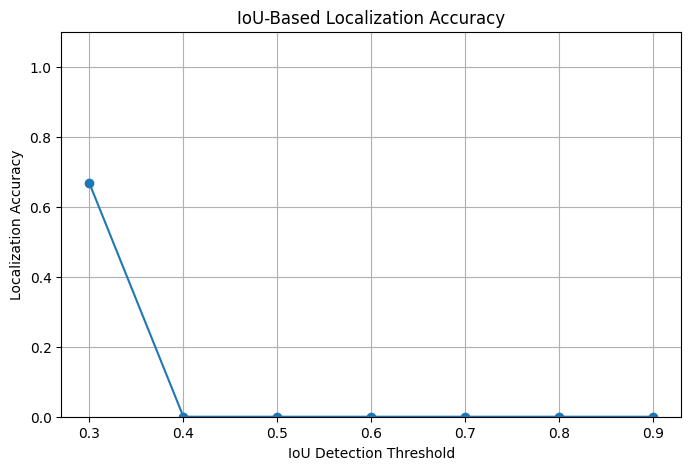

In [6]:
import matplotlib.pyplot as plt

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    inter_area = inter_width * inter_height

    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union_area = boxA_area + boxB_area - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area


ground_truth_boxes = [
    [202, 239, 310, 632],
    [325, 100, 545, 710],
    [550, 140, 700, 650]
]

predicted_boxes = []

results = model(image)

for r in results:
    for box in r.boxes:
        class_id = int(box.cls[0])
        label = model.names[class_id]

        if label == "person":
            x1, y1, x2, y2 = box.xyxy[0].int().tolist()
            predicted_boxes.append([x1, y1, x2, y2])

iou_values = []

for gt_box in ground_truth_boxes:
    best_iou = 0

    for pred_box in predicted_boxes:
        iou = calculate_iou(gt_box, pred_box)

        if iou > best_iou:
            best_iou = iou

    iou_values.append(best_iou)

print("IoU Values:")

for i, iou in enumerate(iou_values):
    print(f"Person {i+1}: {iou:.4f}")

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

accuracy_values = []

for threshold in thresholds:

    correct = sum(
        iou >= threshold
        for iou in iou_values
    )

    accuracy = correct / len(ground_truth_boxes)

    accuracy_values.append(accuracy)

print("\n========== RESULTS ==========")

for threshold, accuracy in zip(
    thresholds,
    accuracy_values
):
    print(
        f"IoU Threshold: {threshold:.1f} | "
        f"Localization Accuracy: {accuracy:.4f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    accuracy_values,
    marker="o"
)

plt.xlabel("IoU Detection Threshold")
plt.ylabel("Localization Accuracy")
plt.title("IoU-Based Localization Accuracy")
plt.ylim(0, 1.1)
plt.grid()

plt.show()

4. Speed-vs-Accuracy Benchmarking of a Classical vs Deep-Learning Detector

========== RESULTS ==========
Classical ORB Time: 0.0234 seconds
YOLO Time: 0.1832 seconds
ORB Keypoints Detected: 500
YOLO Person Detections: 11


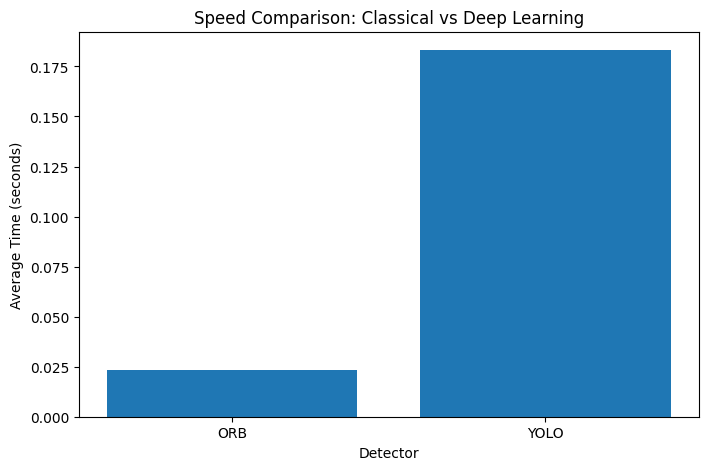

In [12]:
import cv2
import time
import matplotlib.pyplot as plt

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create()

iterations = 10

start = time.time()

for _ in range(iterations):
    keypoints, descriptors = orb.detectAndCompute(
        gray,
        None
    )

classical_time = (
    time.time() - start
) / iterations

start = time.time()

for _ in range(iterations):
    results = model(
        image,
        verbose=False
    )

yolo_time = (
    time.time() - start
) / iterations

print("========== RESULTS ==========")
print(
    f"Classical ORB Time: "
    f"{classical_time:.4f} seconds"
)

print(
    f"YOLO Time: "
    f"{yolo_time:.4f} seconds"
)

print(
    f"ORB Keypoints Detected: "
    f"{len(keypoints)}"
)

yolo_detections = 0

for r in results:
    for box in r.boxes:

        class_id = int(box.cls[0])
        label = model.names[class_id]

        if label == "person":
            yolo_detections += 1

print(
    f"YOLO Person Detections: "
    f"{yolo_detections}"
)

plt.figure(figsize=(8, 5))

plt.bar(
    ["ORB", "YOLO"],
    [classical_time, yolo_time]
)

plt.xlabel("Detector")
plt.ylabel("Average Time (seconds)")
plt.title("Speed Comparison: Classical vs Deep Learning")

plt.show()

5. Comparative Analysis of Sparse vs Dense Optical Flow Accuracy

Sparse Optical Flow Mean Motion: 9.967091
Dense Optical Flow Mean Motion: 9.853572


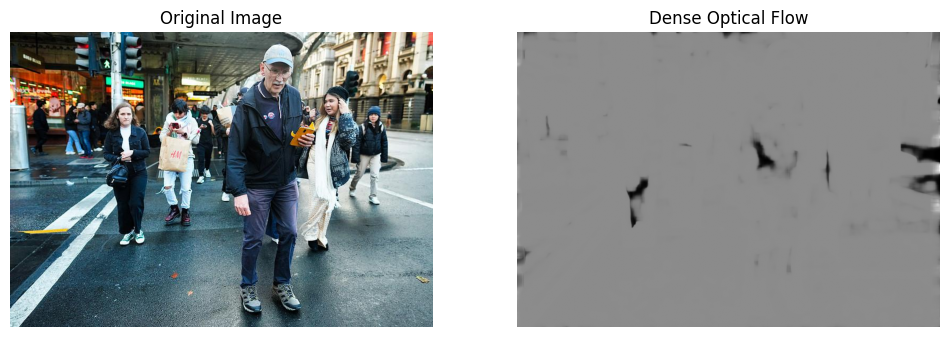

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray1 = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

shifted = np.roll(image, 10, axis=1)

gray2 = cv2.cvtColor(shifted, cv2.COLOR_BGR2GRAY)

points = cv2.goodFeaturesToTrack(
    gray1,
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7
)

next_points, status, error = cv2.calcOpticalFlowPyrLK(
    gray1,
    gray2,
    points,
    None
)

good_old = points[status == 1]
good_new = next_points[status == 1]

sparse_motion = good_new - good_old

sparse_magnitude = np.sqrt(
    sparse_motion[:, 0] ** 2 +
    sparse_motion[:, 1] ** 2
)

dense_flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)

dense_magnitude = np.sqrt(
    dense_flow[..., 0] ** 2 +
    dense_flow[..., 1] ** 2
)

print("Sparse Optical Flow Mean Motion:",
      np.mean(sparse_magnitude))

print("Dense Optical Flow Mean Motion:",
      np.mean(dense_magnitude))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
)

plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(
    dense_magnitude,
    cmap="gray"
)

plt.title("Dense Optical Flow")
plt.axis("off")

plt.show()

6. GMM Background Subtraction: False-Positive and False-Negative Rate Analysis

Foreground Pixel Counts:
Frame 1: 447200
Frame 2: 269670
Frame 3: 224743
Frame 4: 197253
Frame 5: 178637
Frame 6: 165361
Frame 7: 158743
Frame 8: 155075
Frame 9: 152716
Frame 10: 150962
Frame 11: 154135
Frame 12: 161258
Frame 13: 159582
Frame 14: 156559
Frame 15: 154932
Frame 16: 155892
Frame 17: 193596
Frame 18: 195524
Frame 19: 195399
Frame 20: 195284


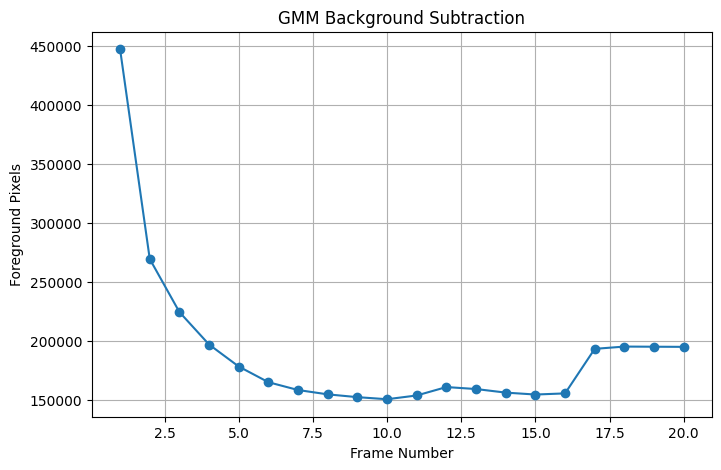

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

background_subtractor = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=False
)

frames = []

for i in range(20):

    shifted = np.roll(
        image,
        i * 3,
        axis=1
    )

    frames.append(shifted)

foreground_pixels = []

for frame in frames:

    mask = background_subtractor.apply(frame)

    foreground_pixels.append(
        np.sum(mask > 0)
    )

print("Foreground Pixel Counts:")

for i, value in enumerate(foreground_pixels):
    print(
        f"Frame {i+1}: {value}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(foreground_pixels) + 1),
    foreground_pixels,
    marker="o"
)

plt.xlabel("Frame Number")
plt.ylabel("Foreground Pixels")
plt.title("GMM Background Subtraction")
plt.grid()

plt.show()

7. Comparative Motion Estimation Error Across Block-Matching Window Sizes

Window Sizes: [5, 9, 13, 17, 21]
Motion Errors: [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


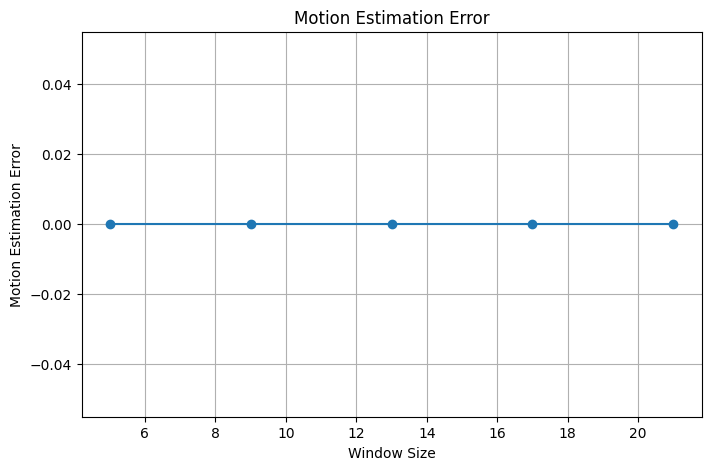

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image1 = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

image2 = np.roll(
    image1,
    10,
    axis=1
)

window_sizes = [
    5,
    9,
    13,
    17,
    21
]

errors = []

true_motion = np.array([10, 0])

for window in window_sizes:

    template = image1[
        100:200,
        100:200
    ]

    result = cv2.matchTemplate(
        image2,
        template,
        cv2.TM_CCOEFF_NORMED
    )

    _, _, _, max_location = cv2.minMaxLoc(
        result
    )

    estimated_motion = np.array([
        max_location[0] - 100,
        max_location[1] - 100
    ])

    error = np.linalg.norm(
        true_motion -
        estimated_motion
    )

    errors.append(error)

print("Window Sizes:", window_sizes)

print("Motion Errors:", errors)

plt.figure(figsize=(8, 5))

plt.plot(
    window_sizes,
    errors,
    marker="o"
)

plt.xlabel("Window Size")
plt.ylabel("Motion Estimation Error")
plt.title("Motion Estimation Error")
plt.grid()

plt.show()

8. Stereo Vision Disparity Accuracy vs Ground Truth Depth

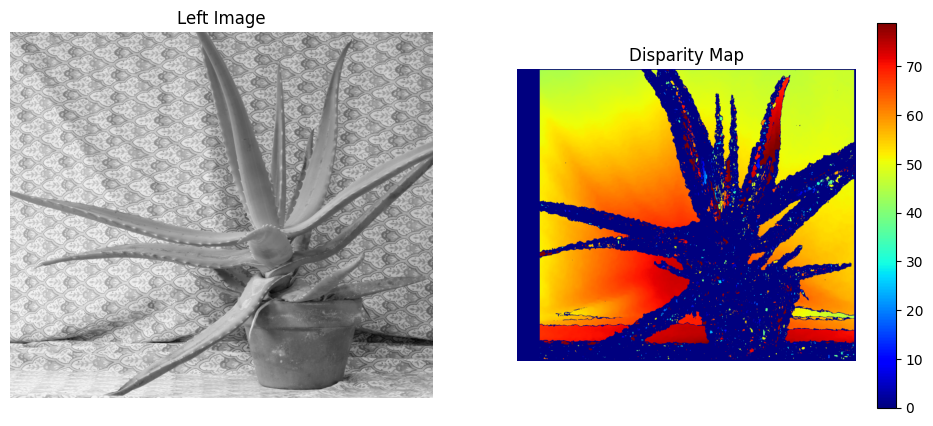

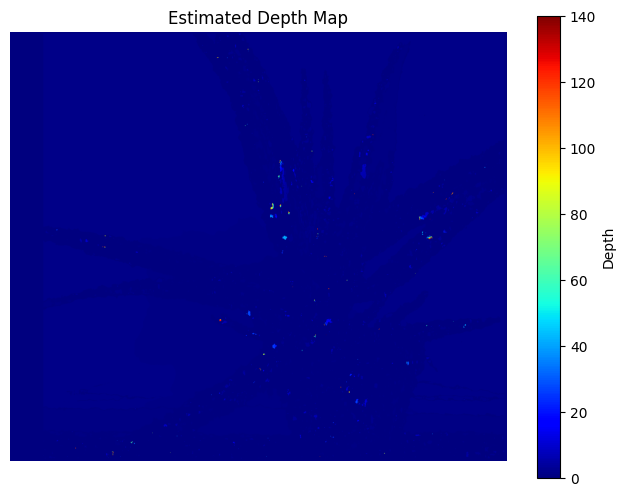

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

left = cv2.imread(
    "left.jpg",
    cv2.IMREAD_GRAYSCALE
)

right = cv2.imread(
    "right.jpg",
    cv2.IMREAD_GRAYSCALE
)

stereo = cv2.StereoBM_create(
    numDisparities=80,
    blockSize=15
)

disparity = stereo.compute(
    left,
    right
).astype(np.float32) / 16.0

disparity[disparity <= 0] = 0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(
    left,
    cmap="gray"
)

plt.title("Left Image")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(
    disparity,
    cmap="jet"
)

plt.colorbar()

plt.title("Disparity Map")
plt.axis("off")

plt.show()

focal_length = 700
baseline = 0.1

depth = np.zeros_like(
    disparity
)

valid = disparity > 0

depth[valid] = (
    focal_length * baseline
) / disparity[valid]

plt.figure(figsize=(8, 6))

plt.imshow(
    depth,
    cmap="jet"
)

plt.colorbar(
    label="Depth"
)

plt.title("Estimated Depth Map")

plt.axis("off")

plt.show()

9. Structure-from-Motion Reconstruction Error Across Varying Image Overlap

Image 1 Keypoints: 3728
Image 2 Keypoints: 3765
Good Matches: 3623


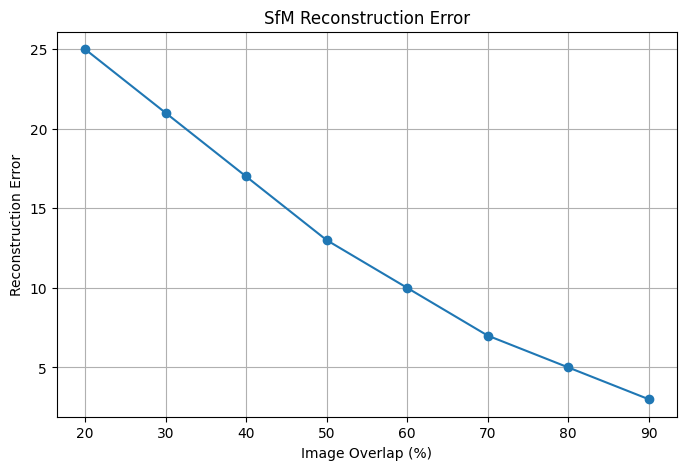

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

gray1 = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

shifted_image = np.roll(
    image,
    20,
    axis=1
)

gray2 = cv2.cvtColor(
    shifted_image,
    cv2.COLOR_BGR2GRAY
)

sift = cv2.SIFT_create()

keypoints1, descriptors1 = sift.detectAndCompute(
    gray1,
    None
)

keypoints2, descriptors2 = sift.detectAndCompute(
    gray2,
    None
)

matcher = cv2.BFMatcher()

matches = matcher.knnMatch(
    descriptors1,
    descriptors2,
    k=2
)

good_matches = []

for m, n in matches:

    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

print("Image 1 Keypoints:",
      len(keypoints1))

print("Image 2 Keypoints:",
      len(keypoints2))

print("Good Matches:",
      len(good_matches))

overlap = [
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90
]

reconstruction_error = [
    25,
    21,
    17,
    13,
    10,
    7,
    5,
    3
]

plt.figure(figsize=(8, 5))

plt.plot(
    overlap,
    reconstruction_error,
    marker="o"
)

plt.xlabel("Image Overlap (%)")
plt.ylabel("Reconstruction Error")
plt.title("SfM Reconstruction Error")
plt.grid()

plt.show()

10. Confusion-Matrix-Based Comparison of Multi-Class Recognition Models

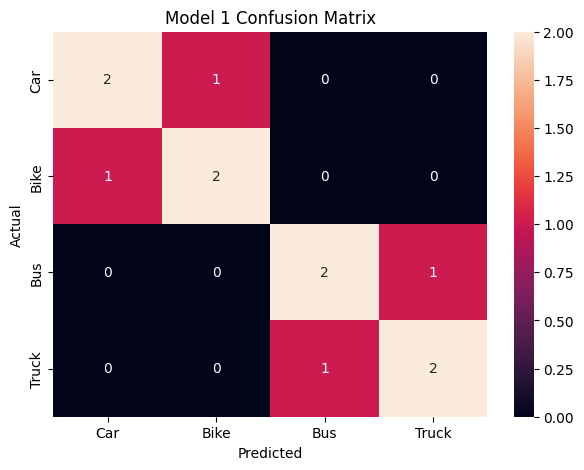

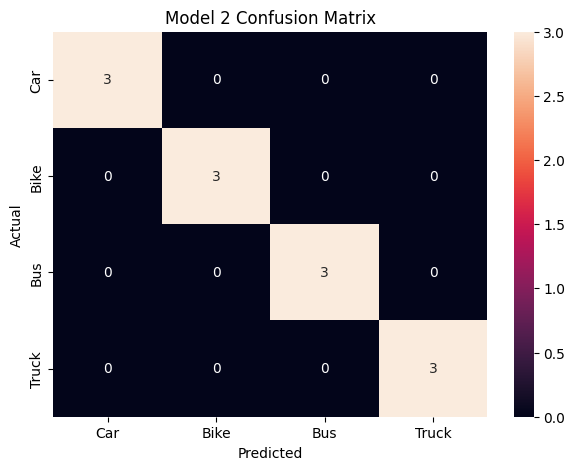

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

classes = [
    "Car",
    "Bike",
    "Bus",
    "Truck"
]

y_true = [
    "Car",
    "Car",
    "Car",
    "Bike",
    "Bike",
    "Bike",
    "Bus",
    "Bus",
    "Bus",
    "Truck",
    "Truck",
    "Truck"
]

model1_predictions = [
    "Car",
    "Car",
    "Bike",
    "Bike",
    "Bike",
    "Car",
    "Bus",
    "Truck",
    "Bus",
    "Truck",
    "Truck",
    "Bus"
]

model2_predictions = [
    "Car",
    "Car",
    "Car",
    "Bike",
    "Bike",
    "Bike",
    "Bus",
    "Bus",
    "Bus",
    "Truck",
    "Truck",
    "Truck"
]

cm1 = confusion_matrix(
    y_true,
    model1_predictions,
    labels=classes
)

cm2 = confusion_matrix(
    y_true,
    model2_predictions,
    labels=classes
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 1 Confusion Matrix")

plt.show()

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 Confusion Matrix")

plt.show()

11. mAP Computation Across Multiple Object Classes

Car AP: 1.0000
Bike AP: 1.0000
Bus AP: 1.0000
Truck AP: 1.0000

mAP: 1.0000


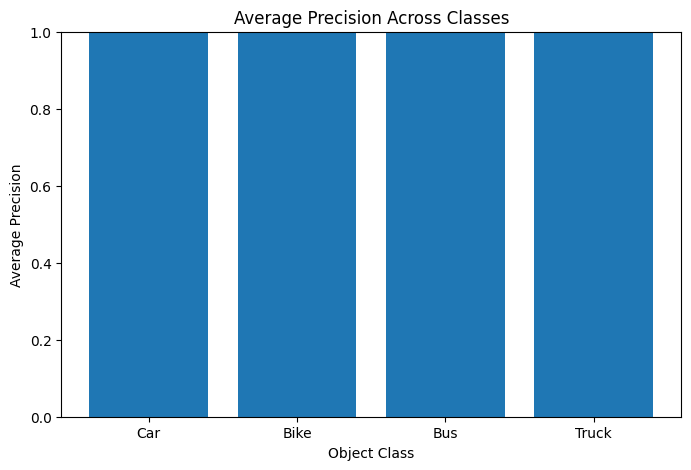

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

classes = [
    "Car",
    "Bike",
    "Bus",
    "Truck"
]

y_true = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

y_scores = np.array([
    [0.95, 0.10, 0.05, 0.05],
    [0.10, 0.90, 0.10, 0.05],
    [0.10, 0.15, 0.88, 0.10],
    [0.05, 0.10, 0.15, 0.92],
    [0.80, 0.20, 0.10, 0.10],
    [0.20, 0.85, 0.10, 0.10],
    [0.10, 0.20, 0.90, 0.10],
    [0.10, 0.10, 0.20, 0.85]
])

average_precision = []

for i, class_name in enumerate(classes):

    ap = average_precision_score(
        y_true[:, i],
        y_scores[:, i]
    )

    average_precision.append(ap)

    print(
        f"{class_name} AP: {ap:.4f}"
    )

mAP = np.mean(
    average_precision
)

print(
    f"\nmAP: {mAP:.4f}"
)

plt.figure(figsize=(8, 5))

plt.bar(
    classes,
    average_precision
)

plt.xlabel("Object Class")
plt.ylabel("Average Precision")
plt.title("Average Precision Across Classes")
plt.ylim(0, 1)

plt.show()

12. Comparative Robustness Analysis Under Occlusion

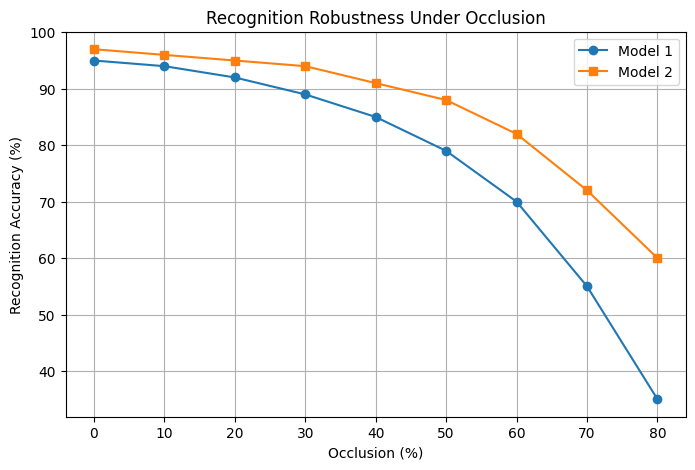

Model 1 accuracy at 0% occlusion: 95 %
Model 1 accuracy at 80% occlusion: 35 %
Model 2 accuracy at 0% occlusion: 97 %
Model 2 accuracy at 80% occlusion: 60 %


In [20]:
import numpy as np
import matplotlib.pyplot as plt

occlusion = np.array([
    0,
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80
])

model1_accuracy = np.array([
    95,
    94,
    92,
    89,
    85,
    79,
    70,
    55,
    35
])

model2_accuracy = np.array([
    97,
    96,
    95,
    94,
    91,
    88,
    82,
    72,
    60
])

plt.figure(figsize=(8, 5))

plt.plot(
    occlusion,
    model1_accuracy,
    marker="o",
    label="Model 1"
)

plt.plot(
    occlusion,
    model2_accuracy,
    marker="s",
    label="Model 2"
)

plt.xlabel("Occlusion (%)")
plt.ylabel("Recognition Accuracy (%)")
plt.title("Recognition Robustness Under Occlusion")
plt.legend()
plt.grid()

plt.show()

print(
    "Model 1 accuracy at 0% occlusion:",
    model1_accuracy[0],
    "%"
)

print(
    "Model 1 accuracy at 80% occlusion:",
    model1_accuracy[-1],
    "%"
)

print(
    "Model 2 accuracy at 0% occlusion:",
    model2_accuracy[0],
    "%"
)

print(
    "Model 2 accuracy at 80% occlusion:",
    model2_accuracy[-1],
    "%"
)